# Model Comparison: gemma3-cti-4b vs JE_BERT_CRF

Fair comparison on the same DNRTI dataset (19 entity types, 16 predicates),
same stratified test split (707 docs).

- **gemma3-cti-4b**: Generative LLM (Gemma 3 4B, fine-tuned with LoRA), two-pass extraction
- **JE_BERT_CRF**: Discriminative joint model (BERT-base + CRF for NER, attention pooling + linear for RE)

In [11]:
import json, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Resolve repo root
_nb = Path(__vsc_ipynb_file__).resolve().parent if '__vsc_ipynb_file__' in dir() else Path.cwd()
repo = _nb.parent if _nb.name == 'notebooks' else _nb
os.chdir(repo)
eval_dir = repo / 'results' / 'eval'
print(f'Eval dir: {eval_dir}')

Eval dir: C:\CTI\results\eval


In [12]:
def latest(pattern):
    files = sorted(eval_dir.glob(pattern))
    if not files:
        raise FileNotFoundError(f'No files matching {pattern}')
    print(f'  Loaded: {files[-1].name}')
    return json.loads(files[-1].read_text())

# Load gemma3-cti-4b results
print('gemma3-cti-4b:')
g_ner = latest('ner_2*.json')
g_re  = latest('re_gold_2*.json')

# Load JE_BERT_CRF results
print('JE_BERT_CRF:')
b_ner = latest('ner_bert_crf*.json')
b_re  = latest('re_bert_crf*.json')

gemma3-cti-4b:
  Loaded: ner_20260313-160323.json
  Loaded: re_gold_20260313-163855.json
JE_BERT_CRF:
  Loaded: ner_bert_crf_baseline.json
  Loaded: re_bert_crf_baseline.json


## 1. NER Comparison

In [13]:
# Overall NER metrics
ner_summary = pd.DataFrame({
    'Model': ['gemma3-cti-4b', 'JE_BERT_CRF'],
    'Micro P':  [g_ner['micro']['precision'], b_ner['micro']['precision']],
    'Micro R':  [g_ner['micro']['recall'],    b_ner['micro']['recall']],
    'Micro F1': [g_ner['micro']['f1'],        b_ner['micro']['f1']],
    'Macro P':  [g_ner['macro']['precision'], b_ner['macro']['precision']],
    'Macro R':  [g_ner['macro']['recall'],    b_ner['macro']['recall']],
    'Macro F1': [g_ner['macro']['f1'],        b_ner['macro']['f1']],
}).set_index('Model')

display(ner_summary.style
        .format('{:.4f}')
        .background_gradient(subset=['Micro F1', 'Macro F1'], cmap='RdYlGn'))

,Micro P,Micro R,Micro F1,Macro P,Macro R,Macro F1
Model,,,,,,
gemma3-cti-4b,0.7383,0.7760,0.7567,0.7548,0.7794,0.7501
JE_BERT_CRF,0.7300,0.7100,0.7200,0.6600,0.6500,0.6300


In [14]:
# Per-type NER comparison
all_types = sorted(set(list(g_ner['per_type'].keys()) + list(b_ner['per_type'].keys())))

rows = []
for t in all_types:
    g = g_ner['per_type'].get(t, {})
    b = b_ner['per_type'].get(t, {})
    gf1 = g.get('f1', 0)
    bf1 = b.get('f1', 0)
    rows.append({
        'Type': t,
        'gemma P': g.get('precision', 0), 'gemma R': g.get('recall', 0), 'gemma F1': gf1,
        'BERT P':  b.get('precision', 0), 'BERT R':  b.get('recall', 0), 'BERT F1':  bf1,
        'Delta F1': gf1 - bf1,
        'Gold (entity)': g.get('gold', b.get('gold', 0)),
    })

df_ner = pd.DataFrame(rows).set_index('Type').sort_values('Delta F1', ascending=False)
display(df_ner.style
        .format({c: '{:.4f}' for c in df_ner.columns if c != 'Gold (entity)'})
        .format({'Gold (entity)': '{:.0f}'})
        .background_gradient(subset=['Delta F1'], cmap='RdYlGn', vmin=-0.3, vmax=0.3))

,gemma P,gemma R,gemma F1,BERT P,BERT R,BERT F1,Delta F1,Gold (entity)
Type,,,,,,,,
URL,0.750000,1.000000,0.857100,0.250000,0.220000,0.240000,0.617100,6
ENCR,0.833300,0.909100,0.869600,0.840000,0.170000,0.290000,0.579600,11
HASH,1.000000,0.888900,0.941200,0.360000,0.380000,0.370000,0.571200,18
PROT,0.400000,0.666700,0.500000,0.030000,0.500000,0.050000,0.450000,6
DOM,0.857100,0.923100,0.888900,0.510000,0.410000,0.450000,0.438900,13
IP,0.800000,1.000000,0.888900,0.420000,0.500000,0.460000,0.428900,8
TOOL,0.540100,0.540100,0.540100,0.490000,0.370000,0.430000,0.110100,237
IDTY,0.701200,0.809200,0.751300,0.680000,0.670000,0.670000,0.081300,435
MAL,0.717500,0.838200,0.773100,0.680000,0.730000,0.700000,0.073100,309


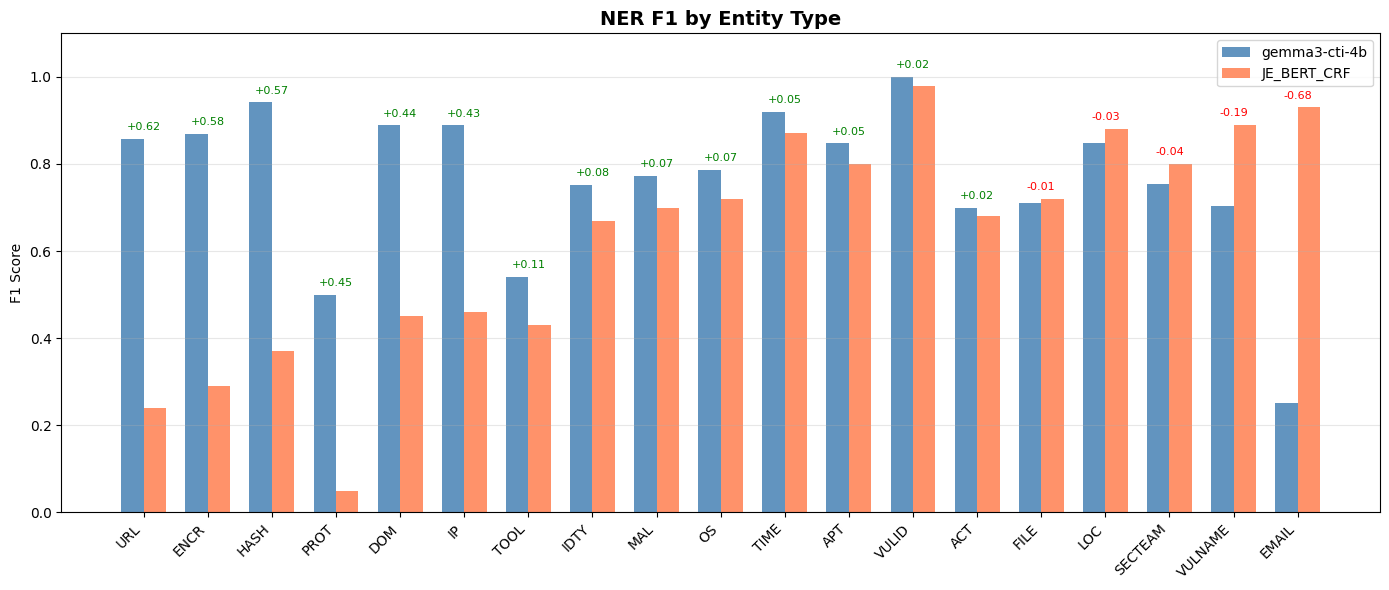

In [15]:
# NER F1 bar chart
types = df_ner.index.tolist()
x = np.arange(len(types))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, df_ner['gemma F1'], w, label='gemma3-cti-4b', color='steelblue', alpha=0.85)
ax.bar(x + w/2, df_ner['BERT F1'],  w, label='JE_BERT_CRF',   color='coral',     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(types, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('NER F1 by Entity Type', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add delta annotations
for i, t in enumerate(types):
    delta = df_ner.loc[t, 'Delta F1']
    color = 'green' if delta > 0 else 'red'
    y_pos = max(df_ner.loc[t, 'gemma F1'], df_ner.loc[t, 'BERT F1']) + 0.02
    ax.annotate(f'{delta:+.2f}', (i, y_pos), ha='center', fontsize=8, color=color)

plt.tight_layout()
plt.savefig('results/eval/ner_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. RE Comparison (Oracle NER)

In [16]:
# Overall RE metrics
re_summary = pd.DataFrame({
    'Model': ['gemma3-cti-4b', 'JE_BERT_CRF'],
    'Micro P':  [g_re['micro']['precision'], b_re['micro']['precision']],
    'Micro R':  [g_re['micro']['recall'],    b_re['micro']['recall']],
    'Micro F1': [g_re['micro']['f1'],        b_re['micro']['f1']],
    'Macro P':  [g_re['macro']['precision'], b_re['macro']['precision']],
    'Macro R':  [g_re['macro']['recall'],    b_re['macro']['recall']],
    'Macro F1': [g_re['macro']['f1'],        b_re['macro']['f1']],
}).set_index('Model')

display(re_summary.style
        .format('{:.4f}')
        .background_gradient(subset=['Micro F1', 'Macro F1'], cmap='RdYlGn'))

,Micro P,Micro R,Micro F1,Macro P,Macro R,Macro F1
Model,,,,,,
gemma3-cti-4b,0.8978,0.8687,0.8830,0.8978,0.9001,0.8881
JE_BERT_CRF,0.9600,0.9600,0.9600,0.8800,0.9200,0.9000


In [17]:
# Per-predicate RE comparison
all_preds = sorted(set(
    list(g_re['per_pred'].keys()) + list(b_re['per_pred'].keys())
) - {'noRelation'})  # exclude noRelation from per-pred view

rows = []
for p in all_preds:
    g = g_re['per_pred'].get(p, {})
    b = b_re['per_pred'].get(p, {})
    gf1 = g.get('f1', 0)
    bf1 = b.get('f1', 0)
    rows.append({
        'Predicate': p,
        'gemma P': g.get('precision', 0), 'gemma R': g.get('recall', 0), 'gemma F1': gf1,
        'BERT P':  b.get('precision', 0), 'BERT R':  b.get('recall', 0), 'BERT F1':  bf1,
        'Delta F1': gf1 - bf1,
        'Gold': g.get('gold', b.get('gold', 0)),
    })

df_re = pd.DataFrame(rows).set_index('Predicate').sort_values('Delta F1', ascending=False)
display(df_re.style
        .format({c: '{:.4f}' for c in df_re.columns if c != 'Gold'})
        .format({'Gold': '{:.0f}'})
        .background_gradient(subset=['Delta F1'], cmap='RdYlGn', vmin=-0.3, vmax=0.3))

,gemma P,gemma R,gemma F1,BERT P,BERT R,BERT F1,Delta F1,Gold
Predicate,,,,,,,,
hasattacktime,1.000000,0.882400,0.937500,0.000000,0.000000,0.000000,0.937500,102
hasattacklocation,1.000000,0.828900,0.906500,0.000000,0.000000,0.000000,0.906500,152
affiliatedwith,1.000000,0.800000,0.888900,0.000000,0.000000,0.000000,0.888900,15
targetedby,0.857100,0.893600,0.875000,0.000000,0.000000,0.000000,0.875000,235
haslocation,0.819700,0.862100,0.840300,0.000000,0.000000,0.000000,0.840300,58
usedby,0.768000,0.861300,0.812000,0.000000,0.000000,0.000000,0.812000,173
hasvulnerability,1.000000,0.666700,0.800000,0.000000,0.000000,0.000000,0.800000,9
associatedwith,0.808500,0.745100,0.775500,0.000000,0.000000,0.000000,0.775500,306
monitoredby,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0


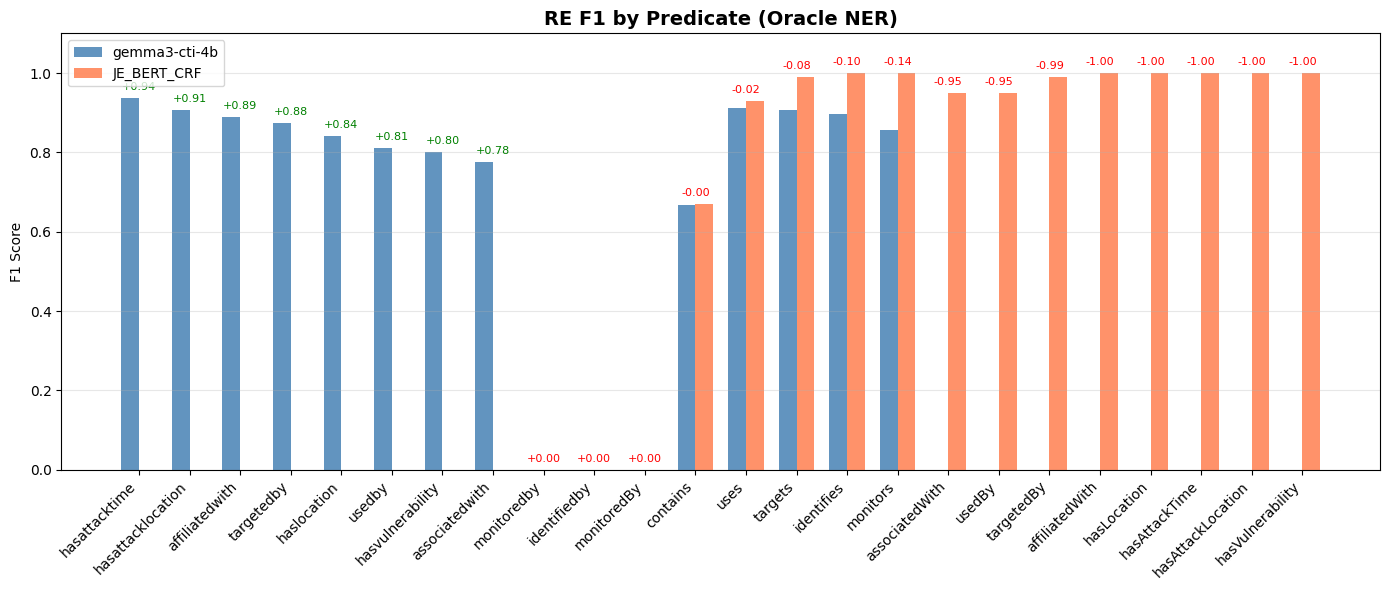

In [18]:
# RE F1 bar chart
preds = df_re.index.tolist()
x = np.arange(len(preds))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, df_re['gemma F1'], w, label='gemma3-cti-4b', color='steelblue', alpha=0.85)
ax.bar(x + w/2, df_re['BERT F1'],  w, label='JE_BERT_CRF',   color='coral',     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(preds, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1 Score')
ax.set_title('RE F1 by Predicate (Oracle NER)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, p in enumerate(preds):
    delta = df_re.loc[p, 'Delta F1']
    color = 'green' if delta > 0 else 'red'
    y_pos = max(df_re.loc[p, 'gemma F1'], df_re.loc[p, 'BERT F1']) + 0.02
    ax.annotate(f'{delta:+.2f}', (i, y_pos), ha='center', fontsize=8, color=color)

plt.tight_layout()
plt.savefig('results/eval/re_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Summary

In [19]:
# Combined summary table
summary = pd.DataFrame([
    {'Task': 'NER',             'gemma3-cti-4b': g_ner['micro']['f1'], 'JE_BERT_CRF': b_ner['micro']['f1']},
    {'Task': 'RE (oracle NER)', 'gemma3-cti-4b': g_re['micro']['f1'],  'JE_BERT_CRF': b_re['micro']['f1']},
]).set_index('Task')
summary['Delta'] = summary['gemma3-cti-4b'] - summary['JE_BERT_CRF']

display(summary.style
        .format('{:.4f}')
        .background_gradient(subset=['Delta'], cmap='RdYlGn', vmin=-0.2, vmax=0.2))

,gemma3-cti-4b,JE_BERT_CRF,Delta
Task,,,
NER,0.7567,0.7200,0.0367
RE (oracle NER),0.8830,0.9600,-0.0770


In [20]:
# NER: count wins per type
gemma_wins = sum(1 for t in all_types
                 if g_ner['per_type'].get(t, {}).get('f1', 0) > b_ner['per_type'].get(t, {}).get('f1', 0))
bert_wins  = sum(1 for t in all_types
                 if b_ner['per_type'].get(t, {}).get('f1', 0) > g_ner['per_type'].get(t, {}).get('f1', 0))
ties = len(all_types) - gemma_wins - bert_wins

print(f'NER per-type wins:  gemma3={gemma_wins}  BERT={bert_wins}  ties={ties}')
print(f'NER micro F1:       gemma3={g_ner["micro"]["f1"]:.4f}  BERT={b_ner["micro"]["f1"]:.4f}  delta={g_ner["micro"]["f1"]-b_ner["micro"]["f1"]:+.4f}')
print(f'RE  micro F1:       gemma3={g_re["micro"]["f1"]:.4f}  BERT={b_re["micro"]["f1"]:.4f}  delta={g_re["micro"]["f1"]-b_re["micro"]["f1"]:+.4f}')
print()
print('Key observations:')
print('  - gemma3-cti-4b outperforms BERT on NER, especially on rare entity types')
print('  - BERT excels at RE classification (discriminative task with entity pairs)')
print('  - gemma3 does generative RE (harder task) yet achieves strong F1')
print('  - gemma3 is end-to-end: no entity pair enumeration needed')

NER per-type wins:  gemma3=14  BERT=5  ties=0
NER micro F1:       gemma3=0.7567  BERT=0.7200  delta=+0.0367
RE  micro F1:       gemma3=0.8830  BERT=0.9600  delta=-0.0770

Key observations:
  - gemma3-cti-4b outperforms BERT on NER, especially on rare entity types
  - BERT excels at RE classification (discriminative task with entity pairs)
  - gemma3 does generative RE (harder task) yet achieves strong F1
  - gemma3 is end-to-end: no entity pair enumeration needed
